In [3]:
import os
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Data_Feb_2026.csv")
df.head()

,X1,X2,X3,X4,Label
0,3.62160,8.6661,-2.8073,-0.44699,0.0
1,4.54590,8.1674,-2.4586,-1.46210,0.0
2,3.86600,-2.6383,1.9242,0.10645,0.0
3,3.45660,9.5228,-4.0112,-3.59440,0.0
4,0.32924,-4.4552,4.5718,-0.98880,0.0


In [6]:
print("Dataset shape:", df.shape)

Dataset shape: (1375, 5)


In [7]:
# Basic structure
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['X1', 'X2', 'X3', 'X4', 'Label']


In [8]:
print("\nData types:")
print(df.dtypes)


Data types:
X1       float64
X2       float64
X3       float64
X4       float64
Label    float64
dtype: object


In [9]:
# Missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
X1       0
X2       0
X3       0
X4       0
Label    1
dtype: int64


In [10]:
print("\nMissing value percentages:")
print((df.isnull().mean() * 100).round(2))


Missing value percentages:
X1       0.00
X2       0.00
X3       0.00
X4       0.00
Label    0.07
dtype: float64


In [11]:
# Exact duplicates
print("\nNumber of exact duplicate rows:")
print(df.duplicated().sum())


Number of exact duplicate rows:
25


In [12]:
# Check for infinite values
numeric_cols = ["X1", "X2", "X3", "X4", "Label"]

print("\nInfinite values:")
print(np.isinf(df[numeric_cols]).sum())


Infinite values:
X1       0
X2       0
X3       0
X4       0
Label    0
dtype: int64


In [13]:
# Unique values and label values
print("\nUnique values per column:")
print(df.nunique())

print("\nLabel distribution before cleaning:")
print(df["Label"].value_counts(dropna=False))


Unique values per column:
X1       1339
X2       1257
X3       1271
X4       1157
Label       2
dtype: int64

Label distribution before cleaning:
Label
0.0    764
1.0    610
NaN      1
Name: count, dtype: int64


In [14]:
# Descriptive statistics
print("\nDescriptive statistics:")
display(df.describe().T)


Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
X1,1375.0,0.386657,3.418977,-70.0000,-1.77470,0.49665,2.82205,6.8248
X2,1375.0,2.014202,6.676094,-13.7731,-1.69785,2.32590,6.81930,120.0000
X3,1375.0,1.359162,4.527056,-50.0000,-1.63045,0.61663,3.18160,17.9274
X4,1375.0,-1.250522,2.987968,-80.0000,-2.42800,-0.58665,0.39481,2.4495
Label,1374.0,0.443959,0.497030,0.0000,0.00000,0.00000,1.00000,1.0000


In [16]:
# Identify the missing label row
missing_label_rows = df[df["Label"].isna()]

print("Rows with missing Label:")
display(missing_label_rows)

Rows with missing Label:


,X1,X2,X3,X4,Label
220,1.3264,1.0326,5.6566,-0.41337,NaN


In [18]:
feature_cols = ["X1", "X2", "X3", "X4"]

# Calculate IQR boundaries
q1 = df[feature_cols].quantile(0.25)
q3 = df[feature_cols].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Mark outliers for each feature
outlier_flags = (
    df[feature_cols].lt(lower_bound) |
    df[feature_cols].gt(upper_bound)
)

# Count how many features mark each row as an outlier
df["outlier_feature_count"] = outlier_flags.sum(axis=1)

# Keep rows that are outliers in at least 3 features
suspected_corrupted_rows = df[df["outlier_feature_count"] >= 3]

print("Suspected corrupted rows:")
display(suspected_corrupted_rows)

Suspected corrupted rows:


,X1,X2,X3,X4,Label,outlier_feature_count
120,-70.0,120.0,-50.0,-80.0,0.0,4


In [19]:
######################################
# Dataset cleaning
######################################

# Start from the original dataset again
clean_df = df.drop(columns=["outlier_feature_count"], errors="ignore").copy()

initial_rows = len(clean_df)

In [20]:
# 1. Remove rows with missing Label
clean_df = clean_df.dropna(subset=["Label"])
after_missing_removal = len(clean_df)

In [21]:
# 2. Remove exact duplicate rows
clean_df = clean_df.drop_duplicates()
after_duplicate_removal = len(clean_df)

In [22]:
# 3. Detect multivariate corrupted outlier using IQR
q1_clean = clean_df[feature_cols].quantile(0.25)
q3_clean = clean_df[feature_cols].quantile(0.75)
iqr_clean = q3_clean - q1_clean

lower_clean = q1_clean - 1.5 * iqr_clean
upper_clean = q3_clean + 1.5 * iqr_clean

outlier_flags_clean = (
    clean_df[feature_cols].lt(lower_clean) |
    clean_df[feature_cols].gt(upper_clean)
)

clean_df["outlier_feature_count"] = outlier_flags_clean.sum(axis=1)

In [23]:
# Remove only rows extreme in at least three features
clean_df = clean_df[clean_df["outlier_feature_count"] < 3].copy()

In [24]:
# Remove helper column
clean_df = clean_df.drop(columns=["outlier_feature_count"])

In [26]:
# Convert Label from float to integer
clean_df["Label"] = clean_df["Label"].astype(int)

final_rows = len(clean_df)

print("Initial number of rows:", initial_rows)
print("Rows after missing Label removal:", after_missing_removal)
print("Rows after duplicate removal:", after_duplicate_removal)
print("Final number of clean rows:", final_rows)

print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())

print("\nDuplicate rows after cleaning:")
print(clean_df.duplicated().sum())

print("\nClean Label distribution:")
print(clean_df["Label"].value_counts().sort_index())

Initial number of rows: 1375
Rows after missing Label removal: 1374
Rows after duplicate removal: 1349
Final number of clean rows: 1348

Missing values after cleaning:
X1       0
X2       0
X3       0
X4       0
Label    0
dtype: int64

Duplicate rows after cleaning:
0

Clean Label distribution:
Label
0    738
1    610
Name: count, dtype: int64


In [27]:
# Save cleaned dataset
clean_df.to_csv("Data_Feb_2026_clean.csv", index=False)

In [28]:
######################################
# Summary statistics
######################################

print("Summary statistics for clean data:")
display(clean_df.describe().T)

print("\nSkewness values:")
print(clean_df[feature_cols].skew())

print("\nCorrelation matrix:")
display(clean_df.corr(numeric_only=True))

Summary statistics for clean data:


,count,mean,std,min,25%,50%,75%,max
X1,1348.0,0.445785,2.862906,-7.0421,-1.78665,0.518735,2.853250,6.8248
X2,1348.0,1.909039,5.868600,-13.7731,-1.62700,2.334150,6.796025,12.9516
X3,1348.0,1.413578,4.328365,-5.2861,-1.54560,0.605495,3.199800,17.9274
X4,1348.0,-1.168712,2.085877,-8.5482,-2.39310,-0.578890,0.403863,2.4495
Label,1348.0,0.452522,0.497925,0.0000,0.00000,0.000000,1.000000,1.0000



Skewness values:
X1   -0.158486
X2   -0.403856
X3    1.088243
X4   -1.017186
dtype: float64

Correlation matrix:


,X1,X2,X3,X4,Label
X1,1.000000,0.272863,-0.387171,0.273993,-0.735185
X2,0.272863,1.000000,-0.785376,-0.520293,-0.449835
X3,-0.387171,-0.785376,1.000000,0.311379,0.154376
X4,0.273993,-0.520293,0.311379,1.000000,-0.033979
Label,-0.735185,-0.449835,0.154376,-0.033979,1.000000


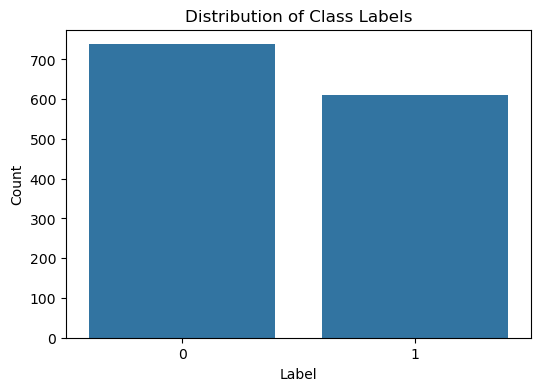

In [30]:
# Label distribution plot
plt.figure(figsize=(6, 4))

sns.countplot(data=clean_df, x="Label")

plt.title("Distribution of Class Labels")
plt.xlabel("Label")
plt.ylabel("Count")

plt.savefig("distribution_class_labels.jpg", dpi=300, bbox_inches="tight")
plt.show()

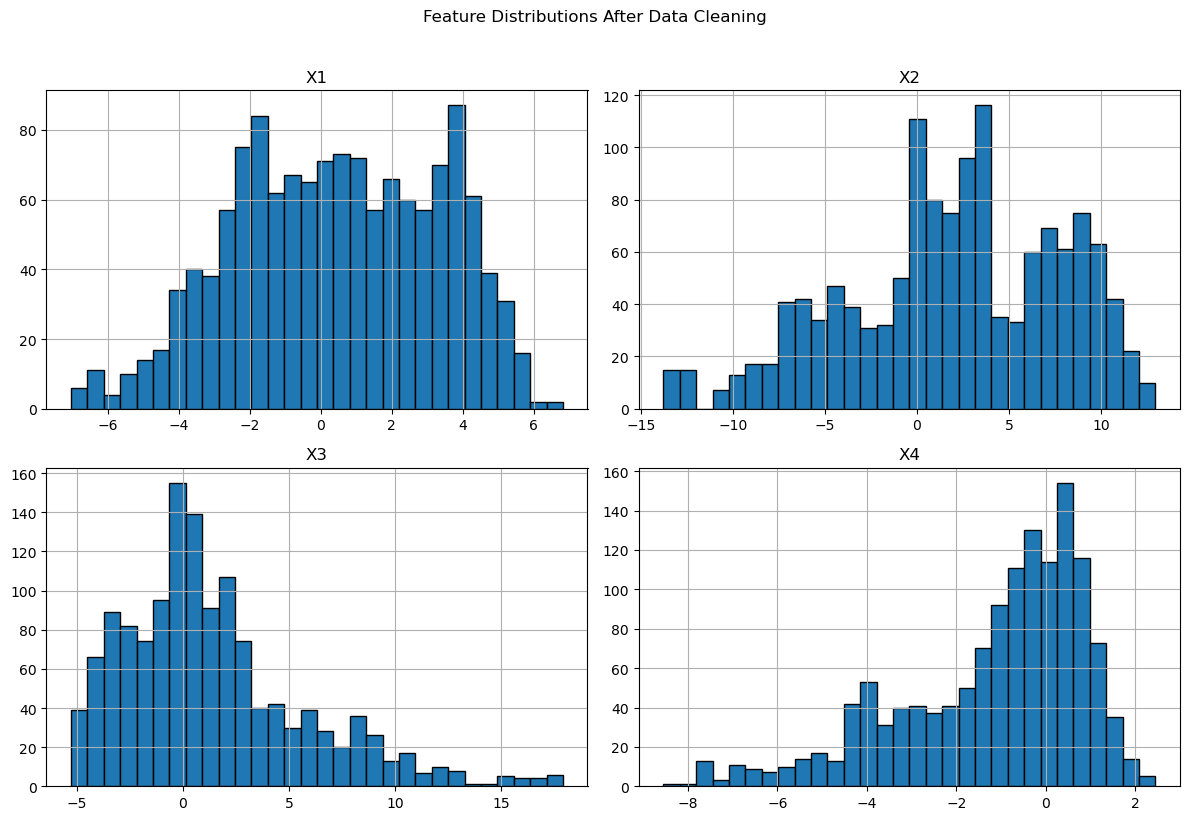

In [31]:
# Histogram for all features
clean_df[feature_cols].hist(
    bins=30,
    figsize=(12, 8),
    edgecolor="black"
)

plt.suptitle("Feature Distributions After Data Cleaning", y=1.02)
plt.tight_layout()

plt.savefig("distribution_all_features.jpg", dpi=300, bbox_inches="tight")
plt.show()

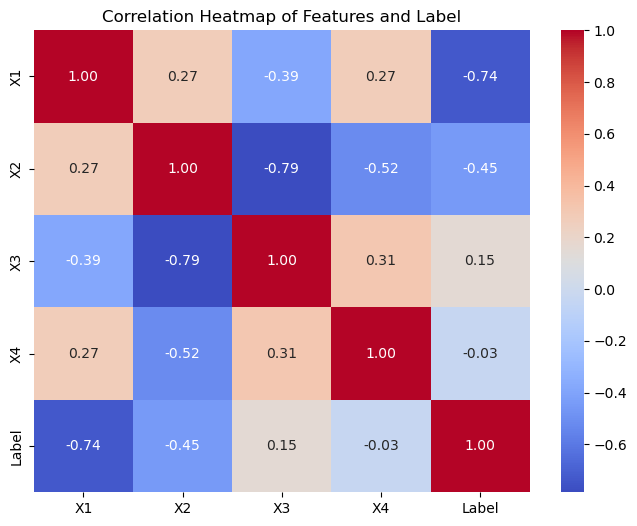

In [32]:
# Correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of Features and Label")

plt.savefig("correlation_heatmap.jpg", dpi=300, bbox_inches="tight")
plt.show()

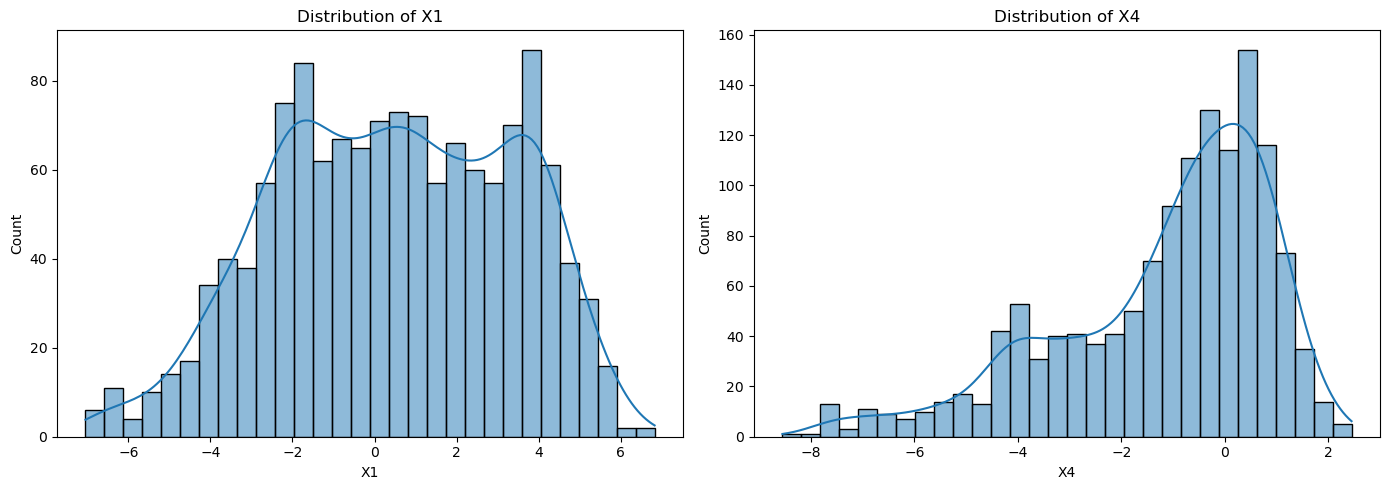

In [35]:
# Compare the distributions of X1 and X4
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=clean_df,
    x="X1",
    bins=30,
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Distribution of X1")

sns.histplot(
    data=clean_df,
    x="X4",
    bins=30,
    kde=True,
    ax=axes[1]
)

axes[1].set_title("Distribution of X4")

plt.tight_layout()
plt.savefig("compare_x1_x4.jpg", dpi=300, bbox_inches="tight")
plt.show()

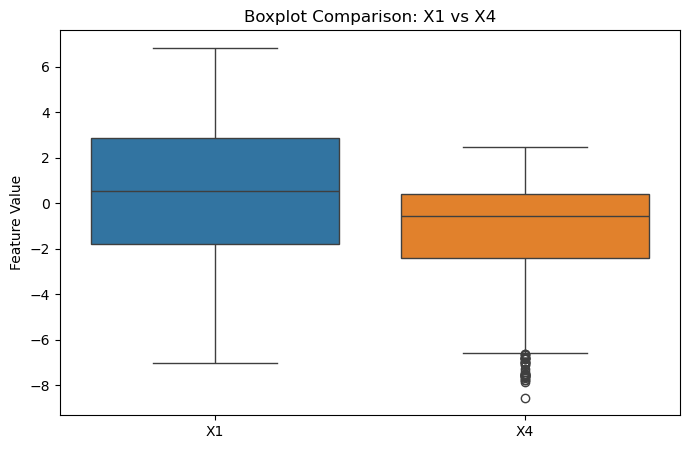

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=clean_df[["X1", "X4"]])

plt.title("Boxplot Comparison: X1 vs X4")
plt.ylabel("Feature Value")

plt.savefig("boxplot_comparison_x1_x4.jpg", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
# Calculate class probabilities
class_counts = clean_df["Label"].value_counts().sort_index()

n_total = len(clean_df)

n_class_0 = class_counts[0]
n_class_1 = class_counts[1]

p_0 = n_class_0 / n_total
p_1 = n_class_1 / n_total

print("Total observations:", n_total)
print("Number of class 0:", n_class_0)
print("Number of class 1:", n_class_1)

print("\nProbability of class 0:", round(p_0, 4))
print("Probability of class 1:", round(p_1, 4))

Total observations: 1348
Number of class 0: 738
Number of class 1: 610

Probability of class 0: 0.5475
Probability of class 1: 0.4525


In [38]:
# Calculate Gini Impurity
gini_impurity = 1 - (p_0 ** 2) - (p_1 ** 2)

print("Gini Impurity:", round(gini_impurity, 4))

Gini Impurity: 0.4955


In [39]:
# Calculate entropy
entropy = -(
    p_0 * np.log2(p_0) +
    p_1 * np.log2(p_1)
)

print("Entropy:", round(entropy, 4))

Entropy: 0.9935


In [40]:
# Predict the misclassification rate
majority_class = 0 if p_0 > p_1 else 1

misclassification_rate = 1 - max(p_0, p_1)

print("Majority class prediction:", majority_class)
print("Baseline Misclassification Rate:", round(misclassification_rate, 4))
print("Baseline Misclassification Rate (%):", round(misclassification_rate * 100, 2), "%")

Majority class prediction: 0
Baseline Misclassification Rate: 0.4525
Baseline Misclassification Rate (%): 45.25 %
